## 02_bar_chart

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/checking-logs.sqlite")
cur = conn.cursor()

### анализируйте только пользователей, а не администраторов

In [2]:
checker = pd.read_sql(
    """
        SELECT timestamp AS date
        FROM checker
        WHERE uid LIKE 'user_%' 
    """,
    conn,
    parse_dates="date",
)
checker

,date
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [3]:
bins = [0, 4, 10, 17, 24]
labels = ["night", "morning", "afternoon", "evening"]
checker["daytime"] = pd.cut(checker.date.dt.hour, bins=bins, labels=labels, right=False)
checker["date"] = checker["date"].dt.date
checker

,date,daytime
0,2020-04-17,morning
1,2020-04-17,morning
2,2020-04-17,morning
3,2020-04-17,morning
4,2020-04-17,morning
...,...,...
3202,2020-05-21,evening
3203,2020-05-21,evening
3204,2020-05-21,evening
3205,2020-05-21,evening


In [4]:
df = checker.groupby("daytime").date.value_counts().unstack(0)
df

C:\Users\79611\AppData\Local\Temp\ipykernel_22996\547028285.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = checker.groupby("daytime").date.value_counts().unstack(0)


daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,33,35
2020-04-19,2,4,16,11
2020-04-20,0,0,12,13
2020-04-21,0,0,0,25
2020-04-22,0,0,4,24
2020-04-23,2,6,15,20
2020-04-24,0,0,4,12
2020-04-25,1,21,33,49


In [5]:
df.count()

daytime
night        35
morning      35
afternoon    35
evening      35
dtype: int64

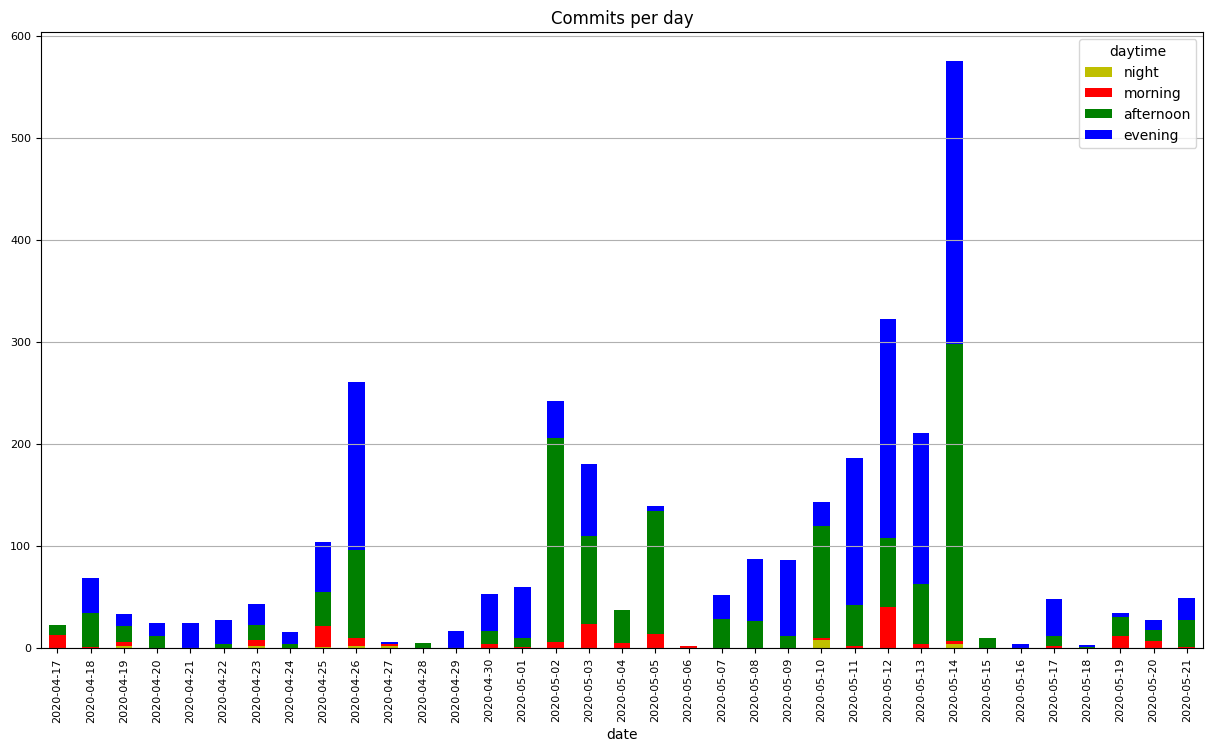

In [6]:
graf = df.plot.bar(
    figsize=(15, 8),
    fontsize=8,
    title="Commits per day",
    rot=90,
    stacked=True,
    color=("y", "r", "g", "b"),
).grid(axis="y")

In [7]:
df.sum()

daytime
night          21
morning       184
afternoon    1391
evening      1611
dtype: int64

### Когда наши пользователи обычно выполняют лабораторные работы: ночью, утром, днём или вечером? — это два наиболее распространённых периода. Ответ - днем и вечером.

In [8]:
print("Answer: ", df[df["evening"] > df["afternoon"]].sum(axis=1).idxmax())

Answer:  2020-05-12


### Который день имеет: наибольшее количество коммитов и в то же время количество коммитов вечером выше, чем днём? Ответ - 05.12.2020

In [9]:
conn.close()